# MLB Historical Analysis: Team Dominance, Championships, and the Impact of the Draft

## Introduction

This project analyzes Major League Baseball (MLB) team performance from 1901 to 2025 to explore long-term dominance, championship distribution, and competitive balance over time.

The analysis is structured around three core questions:

- Which teams have been the most dominant in MLB history?
- How often does the best regular-season team win the World Series?
- Did the introduction of the MLB Draft in 1965 reduce championship concentration and improve competitive balance?

A key strength of this project is the integration of multiple data sources, including manually researched historical records used to complete missing or incomplete information.

## Objectives

- Identify the most dominant teams in MLB history based on winning percentage  
- Analyze whether the best regular-season team wins the World Series  
- Examine the distribution of World Series titles across teams  
- Compare team dominance before and after the introduction of the draft  
- Explore patterns across leagues and special events such as the All-Star Game  

## Sources

- Baseball Reference  
- ESPN  
- Additional manually compiled 2025 data  

## Part 0 - Importing libraries

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create images folder
import os
os.makedirs("images", exist_ok=True)

## Part 1 - Data loading and assembly

In [24]:

# Data loading

# Load the main MLB dataset (includes incomplete 2025 records)
mlb_stats = pd.read_csv("data/mlb_stats_1901_to_2025.csv")

# Load manually compiled datasets for World Series champions and All-Star Game winners

all_star_winner = pd.read_csv("data/All_Star_Game_Winner.csv")
ws_champs = pd.read_csv("data/World_Series_Champion.csv")

# Load the completed 2025 season dataset

mlb_stats_2025 = pd.read_csv("data/2025_stats.csv")


### Handling Incomplete Data (2025 Season)

The 2025 season data is incomplete, so it is removed and replaced with a complete version from an external dataset to ensure accuracy.

In [25]:
# Data assembly

# Remove incomplete 2025 data

mlb_stats = mlb_stats[mlb_stats['year'] != 2025]

# Replace 2025 data with the complete dataset

mlb_stats = pd.concat([mlb_stats, mlb_stats_2025], ignore_index=True)

# Verify that the 2025 data was added correctly

mlb_stats[mlb_stats['year'] == 2025]



,team_name,year,wins,losses,winning_percentage,games_behind,wild_card_games_behind,record_in_the_last_10_games,current_streak,runs_scored,runs_allowed,run_differential,expected_win_loss_record,record_at_home,record_when_away,record_against_top_50_percent
2660,Toronto Blue Jays,2025,94,68,0.580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2661,New York Yankees,2025,94,68,0.580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2662,Boston Red Sox,2025,87,71,0.551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2663,Tampa Bay Rays,2025,77,85,0.475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2664,Baltimore Orioles,2025,75,87,0.463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2665,Cleveland Guardians,2025,88,74,0.543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2666,Detroit Tigers,2025,87,75,0.537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2667,Minnesota Twins,2025,70,92,0.432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2668,Kansas City Royals,2025,82,80,0.506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2669,Seattle Mariners,2025,90,72,0.556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Check column consistency across datasets

print(ws_champs.columns)
print(all_star_winner.columns)

# Standardize all column names to lowercase for consistency

mlb_stats.columns = mlb_stats.columns.str.lower()
ws_champs.columns = ws_champs.columns.str.lower()
all_star_winner.columns = all_star_winner.columns.str.lower()



Index(['year', 'champion'], dtype='object')
Index(['year', 'all star game winner'], dtype='object')


In [27]:
# Merge the auxiliary datasets into the main dataset using the year column

mlb_stats = mlb_stats.merge(ws_champs, on="year", how="left")
mlb_stats = mlb_stats.merge(all_star_winner, on="year", how="left")

# Fill missing All-Star Game values for seasons in which the game was not played

mlb_stats["all star game winner"] = mlb_stats["all star game winner"].fillna("Not played")


## Part 2 - Understanding the Dataset (Data Exploration)

### Dataset Preview

We display the first rows of the dataset to understand its structure, including available columns and data types.

In [28]:
mlb_stats.head(10)

,team_name,year,wins,losses,winning_percentage,games_behind,wild_card_games_behind,record_in_the_last_10_games,current_streak,runs_scored,runs_allowed,run_differential,expected_win_loss_record,record_at_home,record_when_away,record_against_top_50_percent,champion,all star game winner
0,Pittsburgh Pirates,1901,90,49,0.647,NaN,NaN,6-4,W1,776.0,534.0,242.0,92-47,45-24,45-25,47-32,NaN,Not played
1,Chicago White Sox,1901,83,53,0.610,5.5,NaN,5-5,W1,819.0,631.0,188.0,84-52,49-21,34-32,44-34,NaN,Not played
2,Philadelphia Phillies,1901,83,57,0.593,7.5,NaN,7-3,L1,668.0,543.0,125.0,83-57,46-23,37-34,38-42,NaN,Not played
3,Boston Americans,1901,79,57,0.581,9.5,NaN,7-3,W6,759.0,608.0,151.0,82-54,49-20,30-37,40-38,NaN,Not played
4,Brooklyn Superbas,1901,79,57,0.581,9.5,NaN,7-3,W3,744.0,600.0,144.0,81-55,43-25,36-32,41-38,NaN,Not played
5,Detroit Tigers,1901,74,61,0.548,14.0,NaN,5-5,W1,741.0,694.0,47.0,72-63,42-27,32-34,38-37,NaN,Not played
6,Philadelphia Athletics,1901,74,62,0.544,14.5,NaN,8-2,W3,805.0,760.0,45.0,72-64,42-24,32-38,35-41,NaN,Not played
7,St. Louis Cardinals,1901,76,64,0.543,14.5,NaN,8-2,W1,792.0,689.0,103.0,79-61,40-31,36-33,42-38,NaN,Not played
8,Baltimore Orioles,1901,68,65,0.511,19.0,NaN,8-2,L1,760.0,750.0,10.0,67-66,40-25,28-40,34-41,NaN,Not played
9,Boston Beaneaters,1901,69,69,0.500,20.5,NaN,4-6,W1,531.0,556.0,-25.0,66-72,41-29,28-40,31-49,NaN,Not played


### Unique Team Name Values
The unique values reveal potential inconsistencies, such as duplicated teams appearing under different historical names.

In [29]:
mlb_stats.team_name.unique()

array(['Pittsburgh Pirates', 'Chicago White Sox', 'Philadelphia Phillies',
       'Boston Americans', 'Brooklyn Superbas', 'Detroit Tigers',
       'Philadelphia Athletics', 'St. Louis Cardinals',
       'Baltimore Orioles', 'Boston Beaneaters', 'Washington Senators',
       'Cleveland Blues', 'Chicago Orphans', 'New York Giants',
       'Cincinnati Reds', 'Milwaukee Brewers', 'St. Louis Browns',
       'Cleveland Bronchos', 'Chicago Cubs', 'Cleveland Naps',
       'New York Highlanders', 'Boston Red Sox', 'Boston Doves',
       'Brooklyn Dodgers', 'Boston Rustlers', 'Boston Braves',
       'New York Yankees', 'Brooklyn Robins', 'Cleveland Indians',
       'Boston Bees', 'Milwaukee Braves', 'Cincinnati Redlegs',
       'Kansas City Athletics', 'San Francisco Giants',
       'Los Angeles Dodgers', 'Minnesota Twins', 'Los Angeles Angels',
       "Houston Colt 45's", 'New York Mets', 'Houston Astros',
       'Atlanta Braves', 'California Angels', 'Oakland Athletics',
       'Kansas City R

### Team Name Distribution

This step helps identify inconsistencies in team names, such as duplicates or historical variations, which must be standardized before analysis.

In [30]:
mlb_stats.team_name.value_counts()

team_name
Pittsburgh Pirates        124
Philadelphia Phillies     124
Detroit Tigers            124
St. Louis Cardinals       124
Chicago White Sox         123
Chicago Cubs              122
Cincinnati Reds           118
Boston Red Sox            118
New York Yankees          112
Cleveland Indians         107
Baltimore Orioles          74
Washington Senators        70
Los Angeles Dodgers        68
San Francisco Giants       68
Minnesota Twins            65
New York Mets              64
Houston Astros             61
Atlanta Braves             60
Oakland Athletics          58
Milwaukee Brewers          57
San Diego Padres           57
Kansas City Royals         57
New York Giants            56
Texas Rangers              54
Philadelphia Athletics     53
St. Louis Browns           51
Seattle Mariners           49
Toronto Blue Jays          49
Montreal Expos             36
Boston Braves              35
Colorado Rockies           33
California Angels          31
Arizona Diamondbacks       28


## Part 3 - Data Cleaning
Before performing deeper analysis, it is important to clean and standardize the dataset. This includes handling missing values and ensuring consistency in categorical variables.

### Standardizing Team Names

Due to historical changes such as relocations and rebranding, team names must be standardized to ensure consistency and avoid duplication in the analysis.

In [31]:
# Team name mapping dictionary (excluding Washington Senators)
modern_teams = {
    # Yankees / Highlanders
    "Boston Americans": "Boston Red Sox",
    "New York Highlanders": "New York Yankees",

    # Guardians (Cleveland)
    "Cleveland Indians": "Cleveland Guardians",
    "Cleveland Naps": "Cleveland Guardians",
    "Cleveland Blues": "Cleveland Guardians",
    "Cleveland Bronchos": "Cleveland Guardians",

    # Orioles (formerly St. Louis Browns)
    "St. Louis Browns": "Baltimore Orioles",

    # Athletics (Philadelphia → Kansas City → Oakland)
    "Philadelphia Athletics": "Oakland Athletics",
    "Kansas City Athletics": "Oakland Athletics",
    "Athletics": "Oakland Athletics",

    # Braves (Boston → Milwaukee → Atlanta)
    "Boston Braves": "Atlanta Braves",
    "Milwaukee Braves": "Atlanta Braves",
    "Boston Beaneaters": "Atlanta Braves",
    "Boston Bees": "Atlanta Braves",
    "Boston Doves": "Atlanta Braves",
    "Boston Rustlers": "Atlanta Braves",

    # Nationals / Expos
    "Montreal Expos": "Washington Nationals",

    # Dodgers (Brooklyn → LA)
    "Brooklyn Dodgers": "Los Angeles Dodgers",
    "Brooklyn Robins": "Los Angeles Dodgers",
    "Brooklyn Superbas": "Los Angeles Dodgers",

    # Cubs (historical names)
    "Chicago Orphans": "Chicago Cubs",

    # Giants (New York → San Francisco)
    "New York Giants": "San Francisco Giants",

    # Angels (California → Anaheim → Los Angeles)
    "California Angels": "Los Angeles Angels",
    "Anaheim Angels": "Los Angeles Angels",

    # Marlins
    "Florida Marlins": "Miami Marlins",

    # Rays
    "Tampa Bay Devil Rays": "Tampa Bay Rays",

    # Astros (Colt .45s)
    "Houston Colt 45's": "Houston Astros",

    # Brewers (formerly Seattle Pilots)
    "Seattle Pilots": "Milwaukee Brewers",

    # Reds
    "Cincinnati Redlegs": "Cincinnati Reds",

    # Senators → Twins y Rangers
    "Washington Senators": "Minnesota Twins",   # Original Senators franchise
    "Washington Senators (1961-1971)": "Texas Rangers",  # Second Senators franchise
}

# Remove extra spaces and standardize capitalization
mlb_stats["champion"] = mlb_stats["champion"].str.strip()

#(optional, for consistency)
mlb_stats["champion"] = mlb_stats["champion"].str.title()

# Replace former names with new names
mlb_stats["team_name"] = mlb_stats["team_name"].replace(modern_teams)
mlb_stats["champion"] = mlb_stats["champion"].replace(modern_teams)


In [32]:
set(mlb_stats["champion"].unique()) - set(modern_teams.values())


{'Arizona Diamondbacks',
 'Chicago White Sox',
 'Detroit Tigers',
 'Kansas City Royals',
 'New York Mets',
 'Philadelphia Phillies',
 'Pittsburgh Pirates',
 'St. Louis Cardinals',
 'Toronto Blue Jays',
 nan}

In [33]:
# Handle Washington Senators franchise mapping based on year
mlb_stats.loc[(mlb_stats["team_name"] == "Washington Senators") & (mlb_stats["year"] <= 1960), "team_name"] = "Minnesota Twins"
mlb_stats.loc[(mlb_stats["team_name"] == "Washington Senators") & (mlb_stats["year"] >= 1961), "team_name"] = "Texas Rangers"


### Rechecking Team Counts After Standardization

In [34]:
mlb_stats.team_name.value_counts()

team_name
Minnesota Twins          135
Baltimore Orioles        125
Los Angeles Dodgers      124
Boston Red Sox           124
Pittsburgh Pirates       124
Philadelphia Phillies    124
Atlanta Braves           124
Detroit Tigers           124
St. Louis Cardinals      124
Oakland Athletics        124
Chicago Cubs             124
Cleveland Guardians      124
San Francisco Giants     124
Cincinnati Reds          124
Chicago White Sox        123
New York Yankees         122
Los Angeles Angels        65
Houston Astros            64
New York Mets             64
Milwaukee Brewers         58
Kansas City Royals        57
Washington Nationals      57
San Diego Padres          57
Texas Rangers             54
Seattle Mariners          49
Toronto Blue Jays         49
Colorado Rockies          33
Miami Marlins             33
Arizona Diamondbacks      28
Tampa Bay Rays            28
Name: count, dtype: int64

### Assigning Each Team to Its League

In [35]:
# Base dictionary with fixed league assignments
Leagues_fijas = {
    "Baltimore Orioles": "American",
    "Boston Red Sox": "American",
    "Chicago White Sox": "American",
    "Cleveland Guardians": "American",
    "Detroit Tigers": "American",
    "Kansas City Royals": "American",
    "Los Angeles Angels": "American",
    "Minnesota Twins": "American",
    "New York Yankees": "American",
    "Oakland Athletics": "American",
    "Seattle Mariners": "American",
    "Tampa Bay Rays": "American",
    "Texas Rangers": "American",
    "Toronto Blue Jays": "American",

    "Atlanta Braves": "National",
    "Chicago Cubs": "National",
    "Cincinnati Reds": "National",
    "Colorado Rockies": "National",
    "Los Angeles Dodgers": "National",
    "Miami Marlins": "National",
    "Milwaukee Brewers": None,   # special case
    "New York Mets": "National",
    "Philadelphia Phillies": "National",
    "Pittsburgh Pirates": "National",
    "San Diego Padres": "National",
    "San Francisco Giants": "National",
    "St. Louis Cardinals": "National",
    "Washington Nationals": "National",
    "Arizona Diamondbacks": "National"
}

# Assign fixed league
mlb_stats["league"] = mlb_stats["team_name"].map(Leagues_fijas)

# Special cases — league changes in specific years
mlb_stats.loc[
    (mlb_stats["team_name"] == "Houston Astros") & (mlb_stats["year"] <= 2012),
    "league"
] = "National"
mlb_stats.loc[
    (mlb_stats["team_name"] == "Houston Astros") & (mlb_stats["year"] >= 2013),
    "league"
] = "American"

mlb_stats.loc[
    (mlb_stats["team_name"] == "Milwaukee Brewers") & (mlb_stats["year"] <= 1997),
    "league"
] = "American"
mlb_stats.loc[
    (mlb_stats["team_name"] == "Milwaukee Brewers") & (mlb_stats["year"] >= 1998),
    "league"
] = "National"

# ==============================
# Reorder columns
# ==============================
# Place 'league' immediately after 'team_name'
cols = list(mlb_stats.columns)
if "team_name" in cols and "league" in cols:
    team_idx = cols.index("team_name")
    cols.remove("league")
    cols.insert(team_idx + 1, "league")
    mlb_stats = mlb_stats.loc[:, cols]

# Verify order
print(mlb_stats.columns[:10])


Index(['team_name', 'league', 'year', 'wins', 'losses', 'winning_percentage',
       'games_behind', 'wild_card_games_behind', 'record_in_the_last_10_games',
       'current_streak'],
      dtype='object')


### Reviewing the Cleaned Dataset

In [36]:
mlb_stats.head()

,team_name,league,year,wins,losses,winning_percentage,games_behind,wild_card_games_behind,record_in_the_last_10_games,current_streak,runs_scored,runs_allowed,run_differential,expected_win_loss_record,record_at_home,record_when_away,record_against_top_50_percent,champion,all star game winner
0,Pittsburgh Pirates,National,1901,90,49,0.647,NaN,NaN,6-4,W1,776.0,534.0,242.0,92-47,45-24,45-25,47-32,NaN,Not played
1,Chicago White Sox,American,1901,83,53,0.610,5.5,NaN,5-5,W1,819.0,631.0,188.0,84-52,49-21,34-32,44-34,NaN,Not played
2,Philadelphia Phillies,National,1901,83,57,0.593,7.5,NaN,7-3,L1,668.0,543.0,125.0,83-57,46-23,37-34,38-42,NaN,Not played
3,Boston Red Sox,American,1901,79,57,0.581,9.5,NaN,7-3,W6,759.0,608.0,151.0,82-54,49-20,30-37,40-38,NaN,Not played
4,Los Angeles Dodgers,National,1901,79,57,0.581,9.5,NaN,7-3,W3,744.0,600.0,144.0,81-55,43-25,36-32,41-38,NaN,Not played


### Dataset Overview

We check the structure of the dataset using .info().
This shows the number of non-null values per column, their data types, and helps us detect potential issues such as missing data or incorrect data types.


In [37]:

mlb_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2689 entries, 0 to 2688
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   team_name                      2689 non-null   object 
 1   league                         2689 non-null   object 
 2   year                           2689 non-null   int64  
 3   wins                           2689 non-null   int64  
 4   losses                         2689 non-null   int64  
 5   winning_percentage             2689 non-null   float64
 6   games_behind                   2530 non-null   float64
 7   wild_card_games_behind         641 non-null    float64
 8   record_in_the_last_10_games    2660 non-null   object 
 9   current_streak                 2660 non-null   object 
 10  runs_scored                    2660 non-null   float64
 11  runs_allowed                   2660 non-null   float64
 12  run_differential               2660 non-null   f

### Rows Containing Missing Values
After identifying missing values per column, we now display the rows that contain at least one null entry.  
This allows us to see specific cases where information is incomplete

In [38]:
mlb_stats.isna().sum()

team_name                           0
league                              0
year                                0
wins                                0
losses                              0
winning_percentage                  0
games_behind                      159
wild_card_games_behind           2048
record_in_the_last_10_games        29
current_streak                     29
runs_scored                        29
runs_allowed                       29
run_differential                   29
expected_win_loss_record           29
record_at_home                     29
record_when_away                   29
record_against_top_50_percent      29
champion                          105
all star game winner                0
dtype: int64

### Explaining Missing Championship Values

The missing values in the `champion` column are expected for specific seasons:

- **1901**: No World Series was played
- **1904**: No World Series was played
- **1994**: The season ended early due to the players' strike, so no World Series champion was recorded
- **2025**: Missing values were originally caused by incomplete season data and were addressed during data integration


### Descriptive Statistics After Cleaning

Finally, we generate summary statistics for the numerical columns.  
These results are now more reliable because the dataset has been assembled from multiple sources, cleaned, and standardized.


In [39]:
mlb_stats.describe()

,year,wins,losses,winning_percentage,games_behind,wild_card_games_behind,runs_scored,runs_allowed,run_differential
count,2689.000000,2689.000000,2689.000000,2689.000000,2530.000000,641.000000,2660.000000,2660.000000,2660.000000
mean,1972.577538,77.908144,77.894013,0.500010,23.359684,15.669267,690.294737,690.294737,0.000000
std,35.607003,14.443062,14.380703,0.082005,13.089560,9.787858,114.778730,116.635659,118.495533
min,1901.000000,19.000000,17.000000,0.235000,0.500000,0.500000,219.000000,209.000000,-349.000000
25%,1944.000000,69.000000,69.000000,0.444000,13.500000,8.000000,626.000000,622.000000,-81.000000
50%,1978.000000,79.000000,78.000000,0.505000,22.000000,15.000000,694.000000,693.000000,4.000000
75%,2003.000000,88.000000,88.000000,0.558000,32.000000,22.000000,760.000000,763.000000,81.000000
max,2025.000000,116.000000,121.000000,0.763000,68.000000,52.000000,1067.000000,1199.000000,411.000000


## Methodology

To support this analysis, team names were standardized across historical franchise changes, league labels were harmonized, and incomplete 2025 records were replaced with manually compiled season data. Missing championship values were preserved only for seasons in which no World Series champion officially existed.

## Part 4 - Analysis and Visualizations

### Top 10 Teams by Winning Percentage (All-Time)

🏆 Top 10 Historical Teams by Win Percentage:



,team_name,winning_percentage
18,New York Yankees,0.570393
23,San Francisco Giants,0.533282
13,Los Angeles Dodgers,0.532210
25,St. Louis Cardinals,0.520750
3,Boston Red Sox,0.516992
7,Cleveland Guardians,0.515363
4,Chicago Cubs,0.505573
21,Pittsburgh Pirates,0.503742
10,Houston Astros,0.503234
9,Detroit Tigers,0.502492


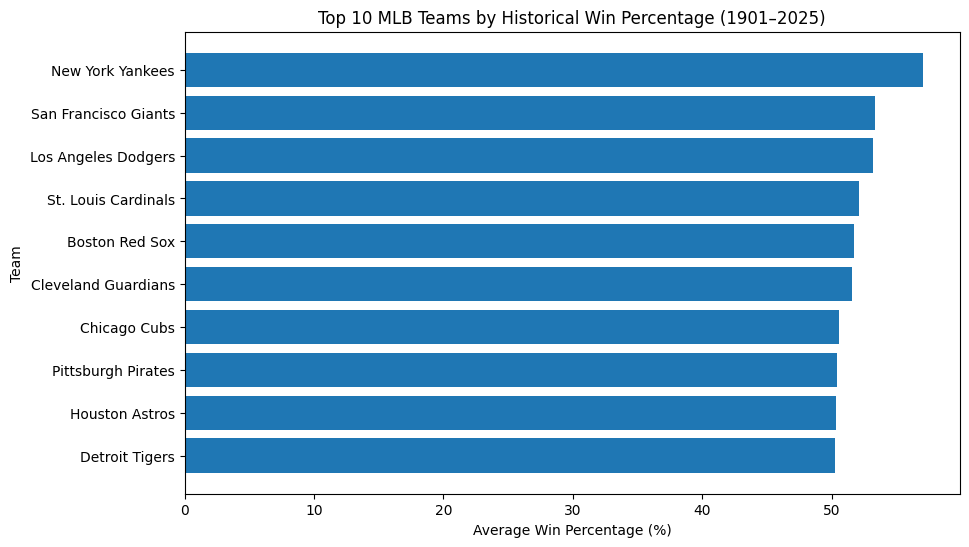

In [40]:
best_teams = (
    mlb_stats.groupby("team_name", as_index=False)["winning_percentage"]
    .mean()
    .sort_values("winning_percentage", ascending=False)
)

print("🏆 Top 10 Historical Teams by Win Percentage:\n")
display(best_teams.head(10))


# Visualization
plt.figure(figsize=(10, 6))
plt.barh(best_teams.head(10)["team_name"], best_teams.head(10)["winning_percentage"] * 100)
plt.title("Top 10 MLB Teams by Historical Win Percentage (1901–2025)")
plt.xlabel("Average Win Percentage (%)")
plt.ylabel("Team")
plt.gca().invert_yaxis()

# Save figure for GitHub README (high resolution)
plt.savefig("images/top_10_win_percentage.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

These results suggest that sustained regular-season success has been concentrated among a relatively small group of franchises, with the Yankees, Dodgers, and Braves consistently ranking near the top across long historical windows.

### Top 5 Teams by League (American vs National)

In [41]:
league_best_teams = (
    mlb_stats_unique.groupby(["league", "team_name"], as_index=False)["winning_percentage"]
    .mean()
)

top5_al = (
    league_best_teams[league_best_teams["league"] == "American"]
    .sort_values("winning_percentage", ascending=False)
    .head(5)
    .set_index("team_name")["winning_percentage"]
)

top5_nl = (
    league_best_teams[league_best_teams["league"] == "National"]
    .sort_values("winning_percentage", ascending=False)
    .head(5)
    .set_index("team_name")["winning_percentage"]
)

print(top5_al)
print(top5_nl)

team_name
Seattle Mariners       0.716000
Oakland Athletics      0.662125
Houston Astros         0.660000
Cleveland Guardians    0.658400
Boston Red Sox         0.650429
Name: winning_percentage, dtype: float64
team_name
Chicago Cubs            0.669429
Pittsburgh Pirates      0.667200
St. Louis Cardinals     0.648000
San Francisco Giants    0.648000
Los Angeles Dodgers     0.646900
Name: winning_percentage, dtype: float64


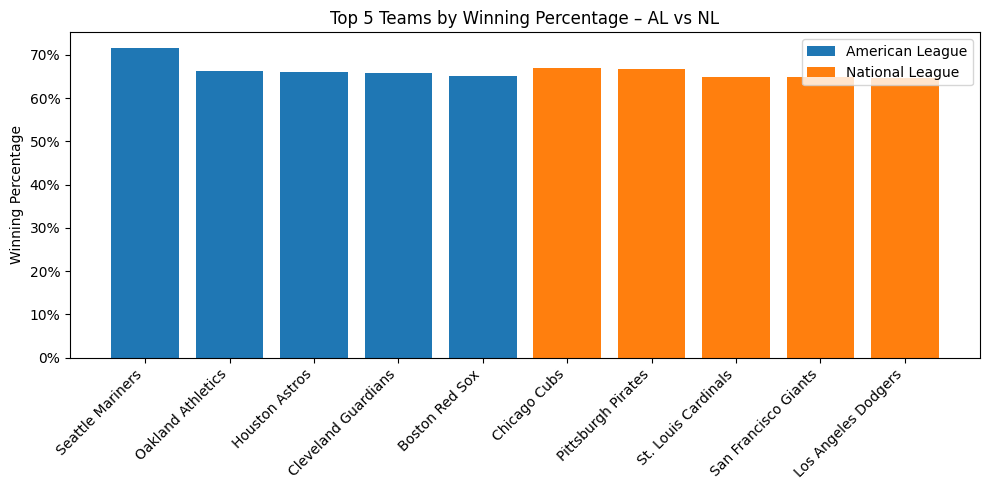

In [42]:
plt.figure(figsize=(10, 5))

plt.bar(top5_al.index, top5_al.values, label="American League")
plt.bar(top5_nl.index, top5_nl.values, label="National League")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Winning Percentage")
plt.title("Top 5 Teams by Winning Percentage – AL vs NL")
plt.legend()

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()

# Save figure for GitHub README (high resolution)
plt.savefig("images/top_5_teams_al_vs_nl.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

This comparison highlights differences in team performance between the American and National leagues, showing how dominance is distributed across both.

### Best Team by Year

This dataset identifies the best team in each season based on winning percentage.

It serves as the foundation for analyzing whether regular-season performance translates into championship success.

In [43]:
best_team_every_year = (
    mlb_stats.loc[mlb_stats.groupby("year")["winning_percentage"].idxmax(),
                  ["year", "team_name", "winning_percentage", "champion"]]
    .sort_values("year")
)

best_team_every_year["won_championship"] = np.where(
    best_team_every_year["team_name"] == best_team_every_year["champion"],
    1, 0
)

best_team_every_year

,year,team_name,winning_percentage,champion,won_championship
0,1901,Pittsburgh Pirates,0.647,NaN,0
16,1902,Pittsburgh Pirates,0.741,NaN,0
32,1903,Boston Red Sox,0.659,Boston Red Sox,1
48,1904,San Francisco Giants,0.693,NaN,0
64,1905,San Francisco Giants,0.686,San Francisco Giants,1
...,...,...,...,...,...
2540,2021,San Francisco Giants,0.660,Atlanta Braves,0
2570,2022,Los Angeles Dodgers,0.685,Houston Astros,0
2600,2023,Atlanta Braves,0.642,Texas Rangers,0
2630,2024,Los Angeles Dodgers,0.605,Los Angeles Dodgers,1


#### Did the Best Regular-Season Team Win the World Series?

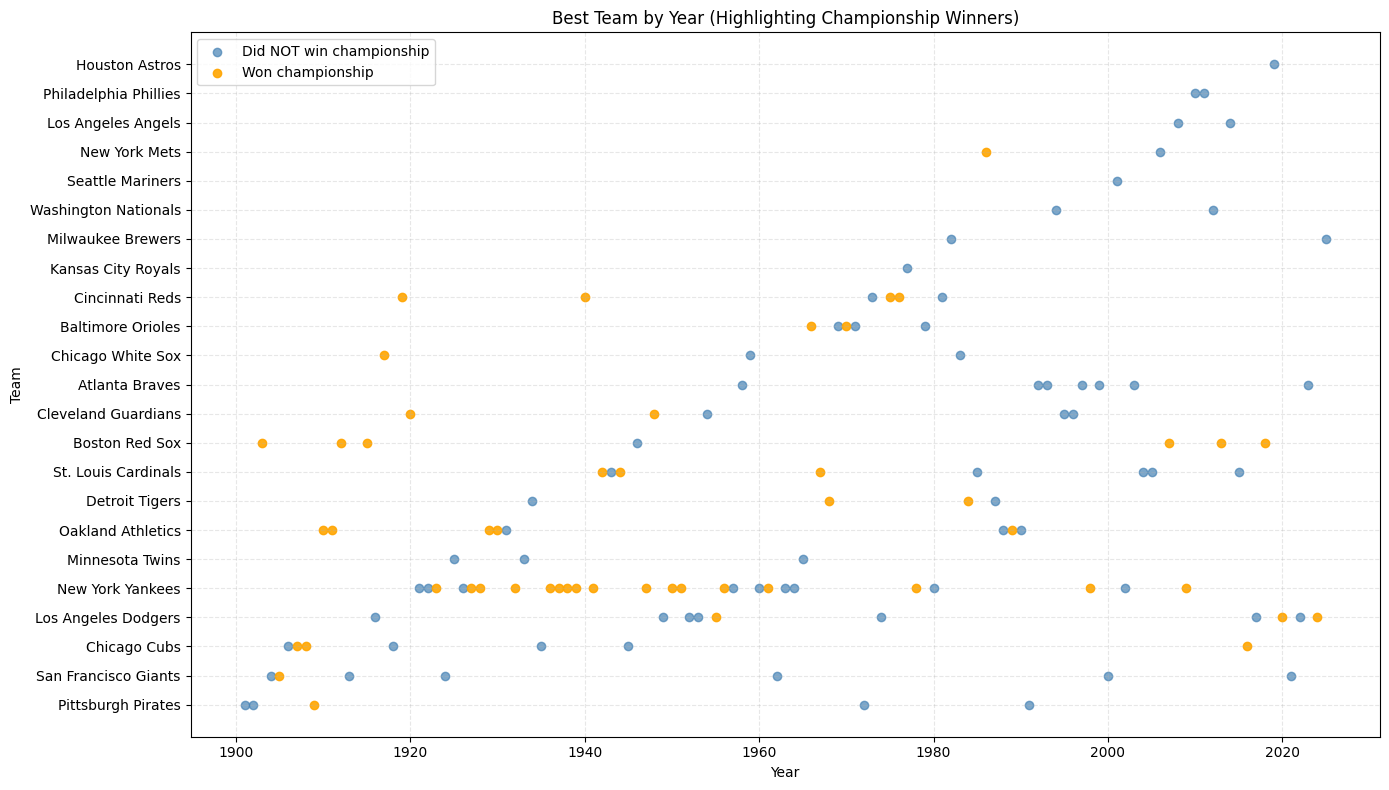

In [44]:
plt.figure(figsize=(14, 8))

# Separating cases
won = best_team_every_year[best_team_every_year["won_championship"] == 1]
lost = best_team_every_year[best_team_every_year["won_championship"] == 0]

# Plot: teams that didnt win (Blue)
plt.scatter(
    lost["year"],
    lost["team_name"],
    color="steelblue",
    label="Did NOT win championship",
    alpha=0.7
)

# Plot: Teams that did win (gold/orange)
plt.scatter(
    won["year"],
    won["team_name"],
    color="orange",
    label="Won championship",
    alpha=0.9
)

plt.title("Best Team by Year (Highlighting Championship Winners)")
plt.xlabel("Year")
plt.ylabel("Team")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

# Save figure for GitHub README (high resolution)
plt.savefig("images/best_team_vs_champion.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

Even the strongest regular-season teams often fail to win the World Series, suggesting that postseason variability plays a significant role in MLB outcomes.

### How Often Did the Best Regular-Season Team Win the World Series?

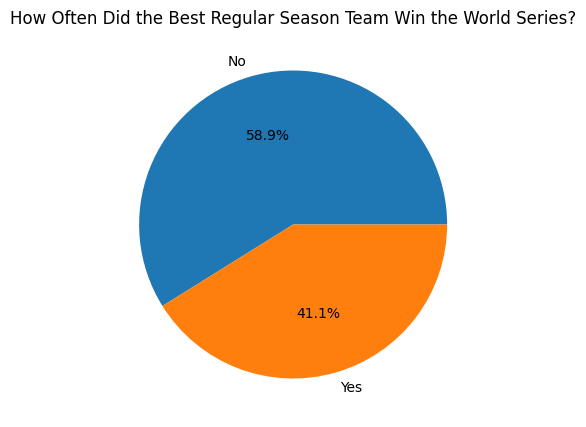

In [45]:
counts = best_team_every_year["won_championship"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=counts.index.map({1: "Yes", 0: "No"}),
    autopct="%1.1f%%"
)
plt.title("How Often Did the Best Regular Season Team Win the World Series?")

# Save figure for GitHub README (high resolution)
plt.savefig("images/best_team_won_world_series_pie.png", dpi=300, bbox_inches="tight")

plt.show()


### Teams with the Most World Series Championships (Top 10)


🏅 Teams with the Most World Series Championships:



,champion,championships_won
0,New York Yankees,27
1,St. Louis Cardinals,11
2,Oakland Athletics,9
3,Boston Red Sox,9
4,Los Angeles Dodgers,8
5,San Francisco Giants,8
6,Cincinnati Reds,5
7,Pittsburgh Pirates,5
8,Detroit Tigers,4
9,Atlanta Braves,3


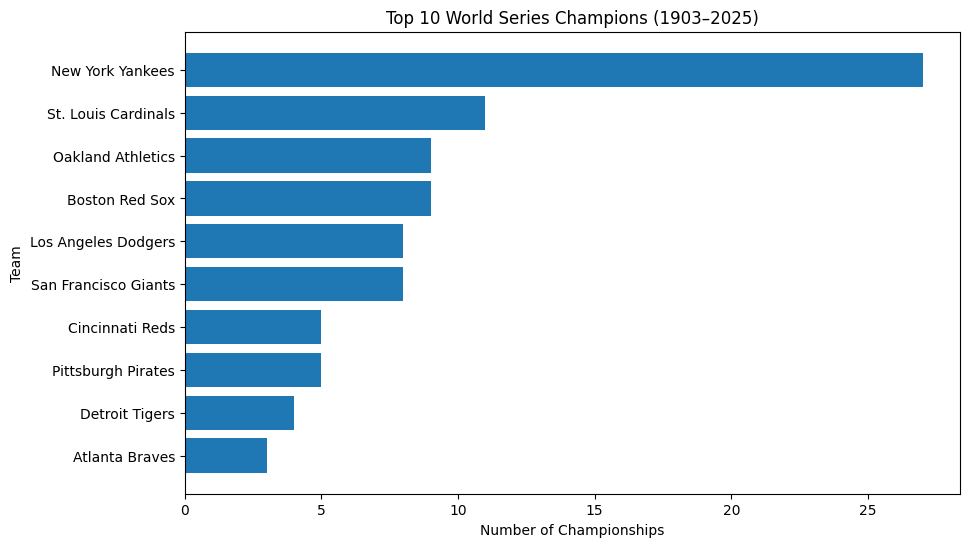

In [46]:
champ_counts = (
    mlb_stats.dropna(subset=["champion"])
    .groupby("champion")["year"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"year": "championships_won"})
)

print("\n🏅 Teams with the Most World Series Championships:\n")
display(champ_counts.head(10))


# Visualization
plt.figure(figsize=(10, 6))
plt.barh(champ_counts.head(10)["champion"], champ_counts.head(10)["championships_won"])
plt.title("Top 10 World Series Champions (1903–2025)")
plt.xlabel("Number of Championships")
plt.ylabel("Team")
plt.gca().invert_yaxis()

# Save figure for GitHub README (high resolution)
plt.savefig("images/top_10_world_series_champions.png", dpi=300, bbox_inches="tight")

plt.show()

### Full Distribution of World Series Titles Across Teams

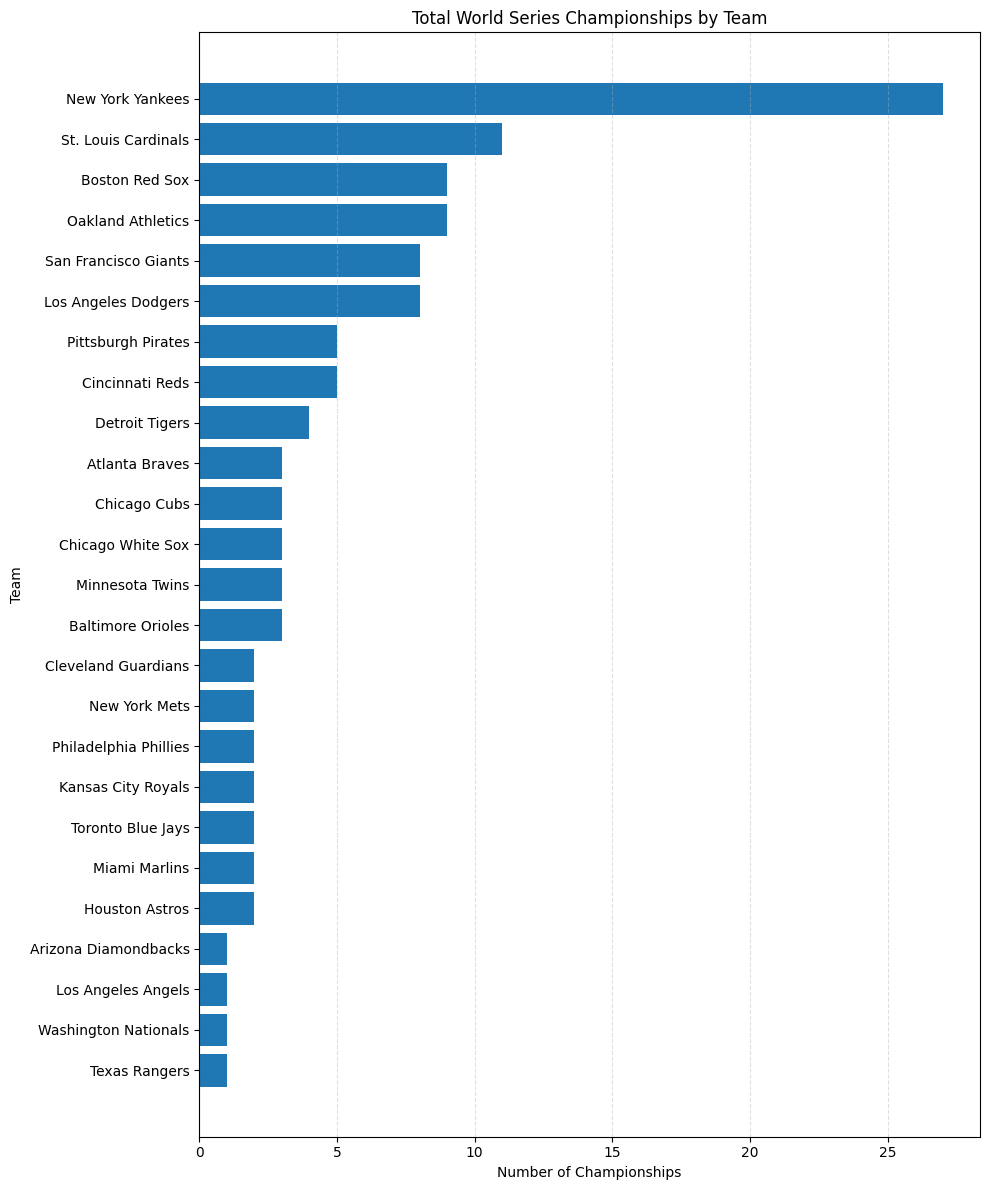

In [47]:
# Use one row per season to avoid double counting championships
clean = mlb_stats.drop_duplicates(subset=["year"])

championship_counts = clean["champion"].value_counts()

plt.figure(figsize=(10, 12))

plt.barh(
    championship_counts.index,
    championship_counts.values
)

plt.title("Total World Series Championships by Team")
plt.xlabel("Number of Championships")
plt.ylabel("Team")

plt.gca().invert_yaxis()  # Display the most successful teams at the top
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save figure for GitHub README (high resolution)
plt.savefig("images/total_championships_by_team.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

A small number of teams account for a large share of total championships, indicating a historically uneven distribution of success.

## The Impact of the Draft (1965)

The MLB Draft was introduced in 1965 to promote competitive balance by giving weaker teams access to top talent.

This section analyzes how team performance and championship distribution changed after its implementation.

### Team Performance Before vs After the Draft

📈 MLB Team Performance Before vs After the Draft (since 1965)



,team_name,all_time_winpct,post_draft_winpct,difference
18,New York Yankees,0.570393,0.556361,-0.014033
13,Los Angeles Dodgers,0.532210,0.549770,0.017561
3,Boston Red Sox,0.516992,0.533705,0.016713
25,St. Louis Cardinals,0.520750,0.527525,0.006775
1,Atlanta Braves,0.489339,0.520967,0.031629
23,San Francisco Giants,0.533282,0.511918,-0.021364
6,Cincinnati Reds,0.499895,0.510311,0.010416
10,Houston Astros,0.503234,0.508082,0.004848
19,Oakland Athletics,0.485234,0.507508,0.022274
2,Baltimore Orioles,0.474576,0.507164,0.032588


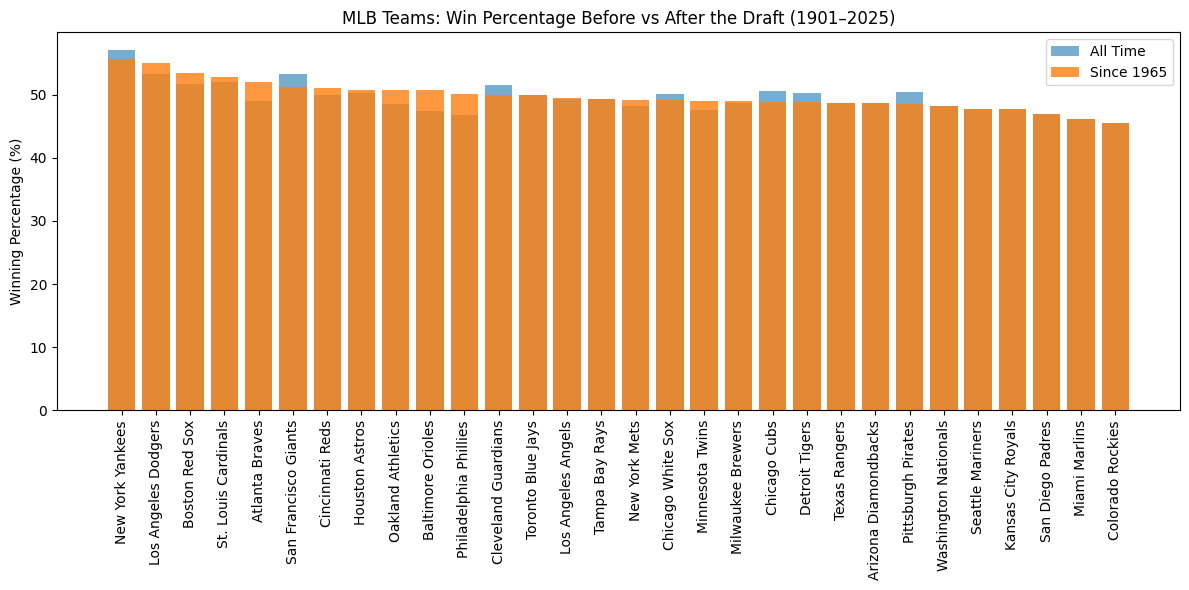

In [48]:
draft_start = 1965

# Historical (all-time) average winning percentage
historical_winpct = (
    mlb_stats.groupby("team_name", as_index=False)["winning_percentage"]
    .mean()
    .rename(columns={"winning_percentage": "all_time_winpct"})
)

# Post-draft (1965–present) average winning percentage
post_draft_winpct = (
    mlb_stats[mlb_stats["year"] >= draft_start]
    .groupby("team_name", as_index=False)["winning_percentage"]
    .mean()
    .rename(columns={"winning_percentage": "post_draft_winpct"})
)

# Merge both datasets
compare_winpct = historical_winpct.merge(post_draft_winpct, on="team_name", how="inner")

# Calculate the change in performance
compare_winpct["difference"] = compare_winpct["post_draft_winpct"] - compare_winpct["all_time_winpct"]

# Sort by best post-draft performance
compare_winpct = compare_winpct.sort_values("post_draft_winpct", ascending=False)

print(f"📈 MLB Team Performance Before vs After the Draft (since {draft_start})\n")
display(compare_winpct.head(10))

# Visualization: comparison between both eras
plt.figure(figsize=(12, 6))
plt.bar(compare_winpct["team_name"], compare_winpct["all_time_winpct"] * 100, label="All Time", alpha=0.6)
plt.bar(compare_winpct["team_name"], compare_winpct["post_draft_winpct"] * 100, label="Since 1965", alpha=0.8)
plt.title("MLB Teams: Win Percentage Before vs After the Draft (1901–2025)")
plt.ylabel("Winning Percentage (%)")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

# Save figure for GitHub README (high resolution)
plt.savefig("images/win_pct_pre_vs_post_draft.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

There is no strong evidence of a significant shift in team win percentages before versus after the introduction of the draft. Overall, performance levels remain relatively stable across both periods, suggesting that the draft had limited impact on regular-season outcomes.

### Pre-Draft Championship Frequency

In [49]:
# Keep only one row per season
mlb_stats_unique = mlb_stats.drop_duplicates(subset=["year"])

In [50]:
# Filter seasons only before the draft
pre_draft = mlb_stats_unique[mlb_stats_unique["year"] < 1965]

# Calculate how many seasons in this period have a recorded champion
total_seasons_pre_draft = pre_draft["champion"].notna().sum()

# value_counts() as in your original code
value_count_pre_draft = pre_draft["champion"].value_counts()

# Convert to percentage
championship_frequency_pre_draft = (
    value_count_pre_draft / total_seasons_pre_draft * 100
).sort_values(ascending=False)

championship_frequency_pre_draft

champion
New York Yankees        33.333333
St. Louis Cardinals     11.666667
Oakland Athletics        8.333333
San Francisco Giants     8.333333
Boston Red Sox           8.333333
Pittsburgh Pirates       5.000000
Los Angeles Dodgers      5.000000
Chicago Cubs             3.333333
Chicago White Sox        3.333333
Cincinnati Reds          3.333333
Detroit Tigers           3.333333
Cleveland Guardians      3.333333
Minnesota Twins          1.666667
Atlanta Braves           1.666667
Name: count, dtype: float64

### Post-Draft Championship Frequency

In [51]:
# Filter seasons only after the draft
post_draft = mlb_stats_unique[mlb_stats_unique["year"] >= 1965]

# Calculate how many seasons in this period have a recorded champion
total_seasons_post_draft = post_draft["champion"].notna().sum()

# value_counts() as in your original code
value_count_post_draft = post_draft["champion"].value_counts()

# Convert to percentage
championship_frequency_post_draft = (
    value_count_post_draft / total_seasons_post_draft * 100
).sort_values(ascending=False)

championship_frequency_post_draft

champion
New York Yankees         11.864407
Los Angeles Dodgers       8.474576
Oakland Athletics         6.779661
St. Louis Cardinals       6.779661
Boston Red Sox            6.779661
San Francisco Giants      5.084746
Cincinnati Reds           5.084746
Baltimore Orioles         5.084746
New York Mets             3.389831
Pittsburgh Pirates        3.389831
Detroit Tigers            3.389831
Philadelphia Phillies     3.389831
Toronto Blue Jays         3.389831
Atlanta Braves            3.389831
Kansas City Royals        3.389831
Minnesota Twins           3.389831
Houston Astros            3.389831
Miami Marlins             3.389831
Arizona Diamondbacks      1.694915
Los Angeles Angels        1.694915
Chicago White Sox         1.694915
Chicago Cubs              1.694915
Washington Nationals      1.694915
Texas Rangers             1.694915
Name: count, dtype: float64

### Comparing Championship Frequency Across Eras

In [52]:
final_comparison = pd.DataFrame({
    "pre_draft_frequency": championship_frequency_pre_draft,
    "post_draft_frequency": championship_frequency_post_draft
}).fillna(0)

final_comparison

,pre_draft_frequency,post_draft_frequency
champion,,
Arizona Diamondbacks,0.000000,1.694915
Atlanta Braves,1.666667,3.389831
Baltimore Orioles,0.000000,5.084746
Boston Red Sox,8.333333,6.779661
Chicago Cubs,3.333333,1.694915
Chicago White Sox,3.333333,1.694915
Cincinnati Reds,3.333333,5.084746
Cleveland Guardians,3.333333,0.000000
Detroit Tigers,3.333333,3.389831


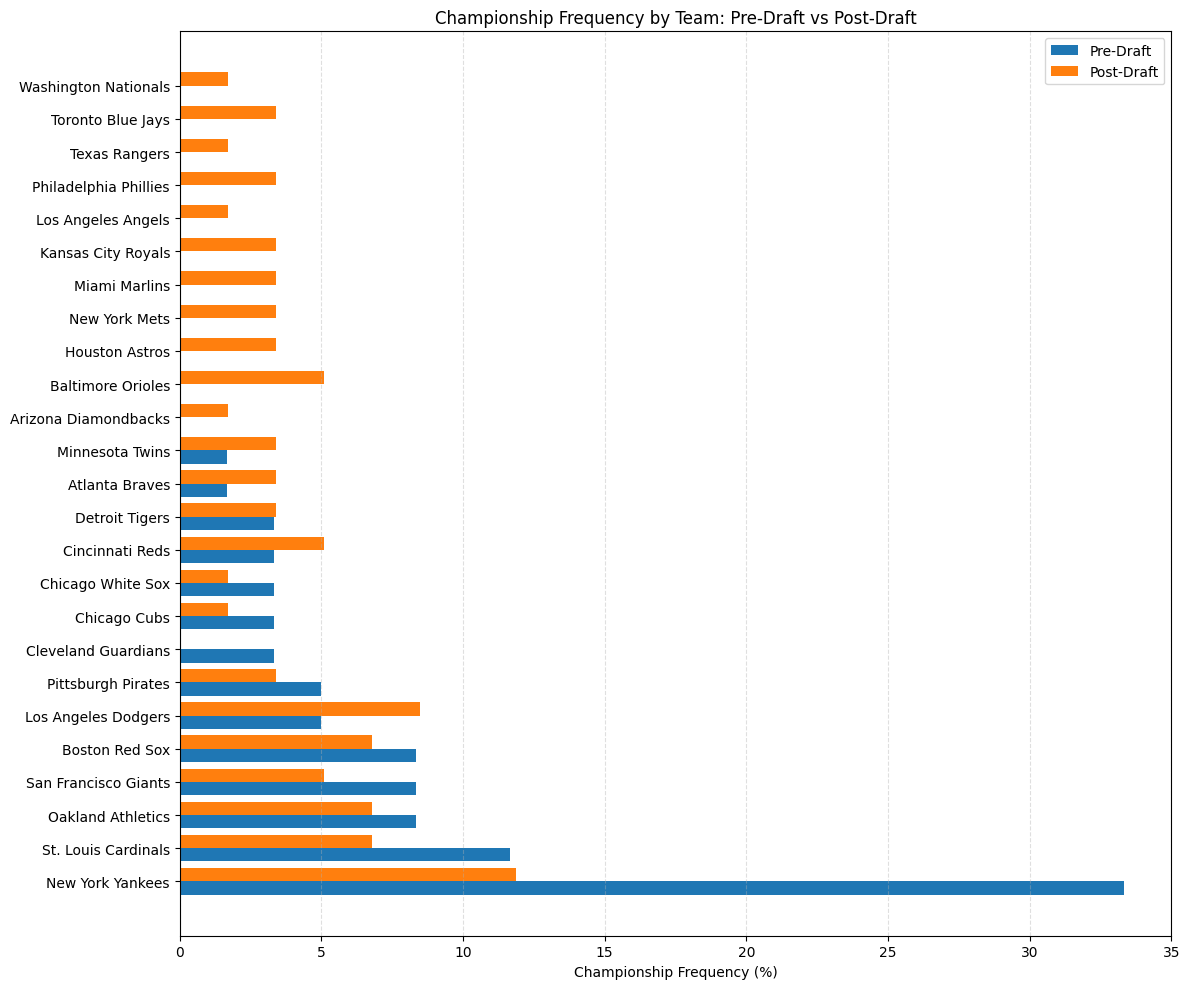

In [53]:
# Sort by pre-draft dominance
df = final_comparison.sort_values("pre_draft_frequency", ascending=False)

# Define bar positions
y = np.arange(len(df))
width = 0.4

plt.figure(figsize=(12, 10))

# Plot bars
plt.barh(y - width/2, df["pre_draft_frequency"], height=width, label="Pre-Draft")
plt.barh(y + width/2, df["post_draft_frequency"], height=width, label="Post-Draft")

# Format labels
plt.yticks(y, df.index)
plt.xlabel("Championship Frequency (%)")
plt.title("Championship Frequency by Team: Pre-Draft vs Post-Draft")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save figure for GitHub README (high resolution)
plt.savefig("images/championship_frequency_pre_post_draft.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

The data shows a clear redistribution of championship success after the introduction of the draft, with historically dominant teams losing share while new teams emerged as consistent contenders.

### World Series Championships Since the Draft (1965–Present)

🏆 World Series Championships by Team Since the Draft (from 1965)



,champion,championships_since_draft
15,New York Yankees,7
11,Los Angeles Dodgers,5
3,Boston Red Sox,4
20,St. Louis Cardinals,4
16,Oakland Athletics,4
2,Baltimore Orioles,3
6,Cincinnati Reds,3
19,San Francisco Giants,3
18,Pittsburgh Pirates,2
14,New York Mets,2


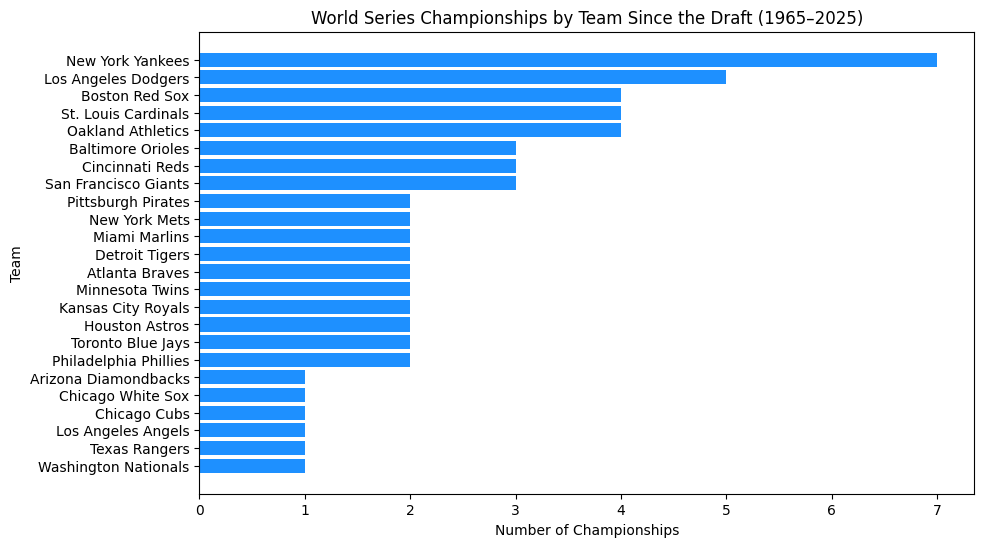

In [54]:
# Define the start year of the draft
draft_start = 1965

# Filter only seasons from 1965 onwards
post_draft_champs = mlb_stats[mlb_stats["year"] >= draft_start]

# Count championships by team (drop duplicates per year to avoid counting multiple rows)
championships_post_draft = (
    post_draft_champs.drop_duplicates(subset=["year", "champion"])
    .dropna(subset=["champion"])
    .groupby("champion", as_index=False)["year"]
    .nunique()
    .rename(columns={"year": "championships_since_draft"})
    .sort_values("championships_since_draft", ascending=False)
)

print(f"🏆 World Series Championships by Team Since the Draft (from {draft_start})\n")
display(championships_post_draft.head(10))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(
    championships_post_draft["champion"],
    championships_post_draft["championships_since_draft"],
    color="#1E90FF",
)
plt.title(f"World Series Championships by Team Since the Draft ({draft_start}–2025)")
plt.xlabel("Number of Championships")
plt.ylabel("Team")
plt.gca().invert_yaxis()

# Save figure for GitHub README (high resolution)
plt.savefig("images/championships_since_draft.png", dpi=300, bbox_inches="tight")

plt.show()


### Which League Wins More Championships?


⚾ Championships by League:



,league,championships
0,American,67
1,National,52


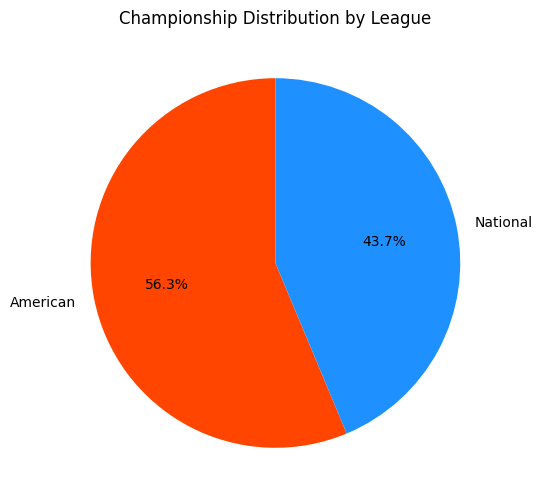

In [55]:
league_champ = (
    mlb_stats.dropna(subset=["champion", "league"])
    .drop_duplicates(subset=["year", "champion"])
    .groupby("league")["year"]
    .nunique()
    .reset_index()
    .rename(columns={"year": "championships"})
)

print("\n⚾ Championships by League:\n")
display(league_champ)

# Visualization
plt.figure(figsize=(6, 6))
plt.pie(
    league_champ["championships"],
    labels=league_champ["league"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[ "#FF4500", "#1E90FF"],
)
plt.title("Championship Distribution by League")

# Save figure for GitHub README (high resolution)
plt.savefig("images/championship_distribution_by_league.png", dpi=300, bbox_inches="tight")

plt.show()


### Does the All-Star Game Predict the World Series Winner?


🌟 Did the All-Star Game Winner’s League Win the World Series?



same_league_won_ws
No     63.709677
Yes    36.290323
Name: proportion, dtype: float64

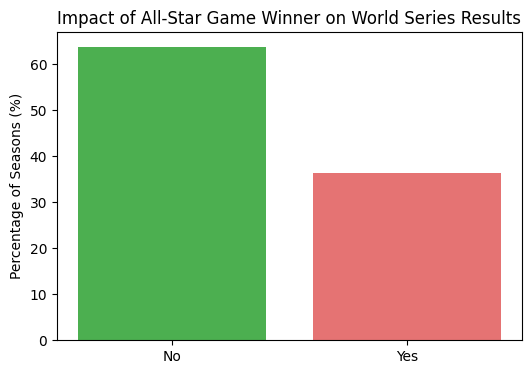

In [56]:
all_star_effect = (
    mlb_stats[["year", "all star game winner", "champion"]]
    .drop_duplicates(subset=["year"])
    .dropna(subset=["all star game winner"])
)

all_star_effect["same_league_won_ws"] = np.where(
    ((all_star_effect["all star game winner"] == "American") & 
     (all_star_effect["champion"].isin(mlb_stats.loc[mlb_stats["league"] == "American", "team_name"].unique()))) |
    ((all_star_effect["all star game winner"] == "National") & 
     (all_star_effect["champion"].isin(mlb_stats.loc[mlb_stats["league"] == "National", "team_name"].unique()))),
    "Yes",
    "No"
)

# Calculate percentage of years where same league won both
summary = all_star_effect["same_league_won_ws"].value_counts(normalize=True) * 100

print("\n🌟 Did the All-Star Game Winner’s League Win the World Series?\n")
display(summary)

# Visualization
plt.figure(figsize=(6, 4))
plt.bar(summary.index, summary.values, color=["#4CAF50", "#E57373"])
plt.title("Impact of All-Star Game Winner on World Series Results")
plt.ylabel("Percentage of Seasons (%)")

# Save figure for GitHub README (high resolution)
plt.savefig("images/all_star_game_vs_world_series.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

The results suggest that winning the All-Star Game is not a meaningful predictor of World Series success.

In [57]:
# Export the cleaned dataset for easier review
mlb_stats.to_csv("data/mlb_stats_final.csv", index=False)


## Part 5 - Conclusions

This analysis shows how MLB history reflects both long-term franchise dominance and the gradual increase in competitive balance after the introduction of the draft.

- A small number of teams, particularly the New York Yankees, historically dominated MLB, especially in the pre-draft era  

- The introduction of the draft in 1965 significantly reduced the concentration of championships and increased competitive balance  

- Despite this shift, the Yankees remain the most dominant franchise even in the post-draft era  

- The best regular-season team does not always win the World Series, highlighting the role of postseason variability  

- Championship success is more evenly distributed in the modern era, indicating greater parity across teams  

